# Image Processing with Pillow

**Pillow** is the friendly Python Imaging Library (a fork of the original PIL). While OpenCV is built for heavy computer vision and video analysis, Pillow is perfect for everyday image manipulation: resizing, cropping, filtering, and drawing.

Unlike OpenCV, Jupyter Notebooks know exactly how to display Pillow `Image` objects automatically—no Matplotlib required! Just put the image variable at the end of a cell.

## 1. Creating and Inspecting an Image

You typically load an image using `Image.open('filename.jpg')`. For this tutorial, we will create a blank image from scratch so this notebook is fully self-contained.

Image Format: None (None because it's generated in memory)
Image Mode: RGB
Image Size: (400, 300)


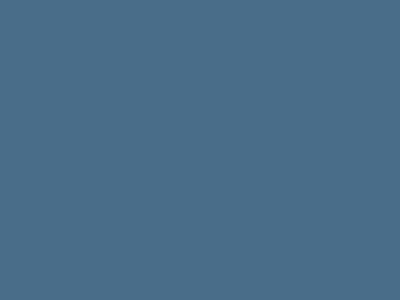

In [1]:
from PIL import Image, ImageDraw, ImageFilter, ImageEnhance

# Create a new RGB image: size (width=400, height=300), background color (R, G, B)
base_img = Image.new('RGB', (400, 300), color=(73, 109, 137))

print(f"Image Format: {base_img.format} (None because it's generated in memory)")
print(f"Image Mode: {base_img.mode}")
print(f"Image Size: {base_img.size}")

# Display it by simply placing the variable at the end of the cell
base_img

## 2. Drawing on the Image

The `ImageDraw` module allows you to add 2D graphics to your images. Let's add some shapes so we have something interesting to manipulate.

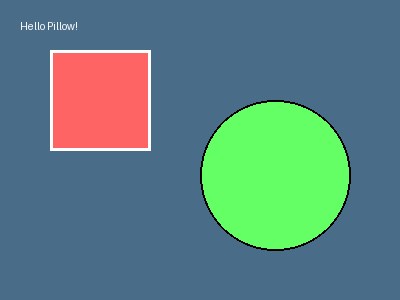

In [2]:
# Create a drawing object associated with our image
draw = ImageDraw.Draw(base_img)

# Draw a rectangle: [x0, y0, x1, y1]
draw.rectangle([50, 50, 150, 150], fill=(255, 100, 100), outline="white", width=3)

# Draw an ellipse (circle): [x0, y0, x1, y1]
draw.ellipse([200, 100, 350, 250], fill=(100, 255, 100), outline="black", width=2)

# Draw some text
draw.text((20, 20), "Hello Pillow!", fill="white")

# Display the updated image
base_img

## 3. Resizing and Cropping

These are the most common operations for preparing images for machine learning pipelines or web display.

Resized dimensions: (200, 150)
Cropped dimensions: (150, 150)


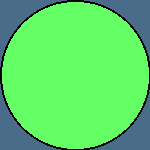

In [3]:
# --- Resizing ---
# Pass a tuple of (width, height)
small_img = base_img.resize((200, 150))
print(f"Resized dimensions: {small_img.size}")

# --- Cropping ---
# Define a box tuple: (left, upper, right, lower)
crop_box = (200, 100, 350, 250)
cropped_img = base_img.crop(crop_box)
print(f"Cropped dimensions: {cropped_img.size}")

# Display the cropped image (the green circle)
cropped_img

## 4. Flipping and Rotating

Pillow uses the `transpose()` method for standard flips and 90-degree rotations, and `rotate()` for arbitrary angles.

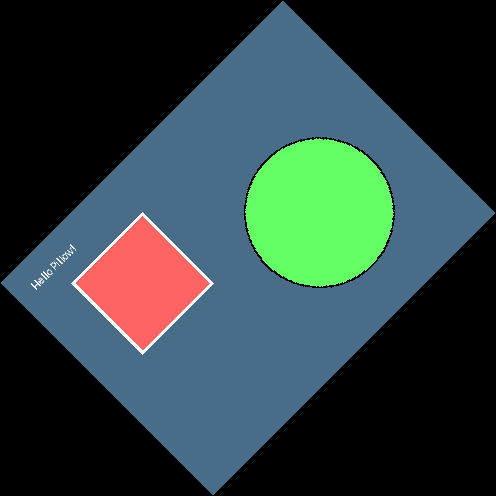

In [4]:
# Flip left-to-right (Mirror)
mirrored = base_img.transpose(Image.FLIP_LEFT_RIGHT)

# Rotate arbitrarily by 45 degrees
# expand=True resizes the canvas so the corners don't get cut off
rotated = base_img.rotate(45, expand=True)

rotated

## 5. Image Filters

The `ImageFilter` module provides standard filters like blur, contour, edge enhancement, and more.

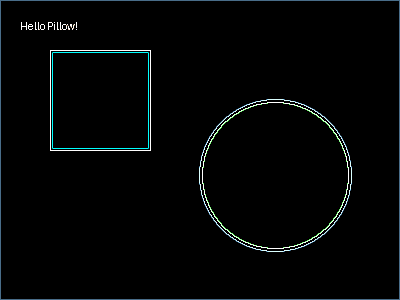

In [5]:
# Apply a Gaussian Blur
blurred_img = base_img.filter(ImageFilter.GaussianBlur(radius=5))

# Find Edges
edges_img = base_img.filter(ImageFilter.FIND_EDGES)

edges_img

## 6. Image Enhancements

The `ImageEnhance` module allows you to adjust color balance, contrast, brightness, and sharpness. You create an enhancer object and then apply a factor (1.0 is original, < 1.0 reduces, > 1.0 increases).

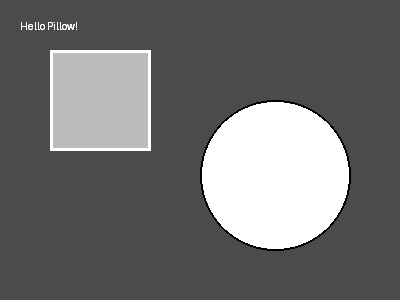

In [6]:
# Create a color enhancer
enhancer = ImageEnhance.Color(base_img)

# Turn the image completely to grayscale (0.0 color)
grayscale_img = enhancer.enhance(0.0)

# Increase contrast
contrast_enhancer = ImageEnhance.Contrast(grayscale_img)
high_contrast_img = contrast_enhancer.enhance(2.5)

high_contrast_img

# To save any image in Pillow, you would use:
# high_contrast_img.save('output.jpg')